# Ejercicio A-2 — Modelado de ley y de falla

Predicción de la **ley de oro del turno siguiente** y de la **falla mecánica en las próximas
cuatro horas**, sobre el extracto `OP_AURUM_extract.csv` de OPUS-MINE.

Todo el código que este notebook ejecuta vive en `aurum_pipeline.modeling` y tiene pruebas.
Aquí solo se narra el resultado: el notebook no es el lugar donde se decide.

**Índice**

1. [Respuesta obligatoria: por qué `prod_estimada_oz` no entra como feature](#obligatoria)
2. [Matriz supervisada y partición](#matriz)
3. [Regresión de la ley](#regresion)
4. [SHAP: qué predice la ley](#shap)
5. [Clasificación de falla a 4 horas](#falla)
6. [Conclusiones](#conclusiones)

<a id="obligatoria"></a>
## 1. Respuesta obligatoria

> **¿Por qué NO debes usar `prod_estimada_oz` como feature de entrada para predecir
> `ley_au_gpT` sin un análisis previo?**

La respuesta está en la celda siguiente, como bloque de comentario en el código, tal como lo
exige el enunciado. La celda además **reproduce la evidencia numérica** sobre el extracto: no
es una afirmación, es una medición que se puede volver a correr.

In [1]:
# =====================================================================================
# RESPUESTA OBLIGATORIA
#
# ¿Por qué NO usar prod_estimada_oz como feature para predecir ley_au_gpT sin analizarla?
#
# Porque no es un sensor: es el objetivo despejado. El diccionario ya lo advierte —"calculada,
# no medida directamente"— y el extracto lo confirma: prod_estimada_oz es una función
# determinista e invertible de la propia ley.
#
#     prod_estimada_oz = ley_au_gpT * ton_rom_acum / 31.1035 * recuperacion(tipo_mineral)
#
# Los dos argumentos son en el fondo el mismo, visto desde dos lados:
#
# 1. CIRCULARIDAD ALGEBRAICA. ton_rom_acum y tipo_mineral están en el mismo archivo, así que
#    la ley se despeja exactamente. Un modelo que reciba prod_estimada_oz no predice: invierte
#    una ecuación. Daría R² ≈ 1 en validación y cero capacidad real, porque en el turno que se
#    quiere anticipar esa producción todavía no existe.
#
# 2. PROCEDENCIA. prod_estimada_oz es una salida del modelo interno de OPUS, no una medición
#    independiente. Entrenar contra ella significa aprender a reproducir la estimación de OPUS
#    y no la geología: si operaciones ajusta el factor de recuperación, el modelo se rompe en
#    silencio, sin error visible y con las métricas intactas.
#
# El matiz del enunciado —"sin un análisis previo"— importa: la variable no está prohibida,
# está prohibido usarla a ciegas. El análisis previo es exactamente el de abajo, y consiste en
# preguntarse si la variable es derivada del objetivo o una medición independiente. Si
# prod_estimada_oz viniera del balance metalúrgico de planta, aguas abajo y con desfase, sería
# una feature legítima como rezago. En este extracto no lo es, y por eso queda fuera.
# =====================================================================================

import logging
import os
import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# El notebook se lee y se ejecuta solo, sin instalar el paquete: la raiz del repositorio se
# deduce del directorio de trabajo, igual que en pipeline_demo.ipynb.
RAIZ = next(padre for padre in Path.cwd().resolve().parents if (padre / "modulo_a").exists())     if not (Path.cwd() / "modulo_a").exists() else Path.cwd().resolve()
sys.path.insert(0, str(RAIZ / "modulo_a"))

from aurum_pipeline import domain  # noqa: E402

logging.basicConfig(level=logging.WARNING, format="%(levelname)-7s %(message)s", force=True)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)


def localizar_extracto(nombre: str = "OP_AURUM_extract.csv") -> Path:
    """Ubica el extracto sin escribir rutas absolutas en el notebook."""
    del_entorno = os.environ.get("AURUM_CSV_PATH")
    if del_entorno:
        return Path(del_entorno).expanduser().resolve()
    for candidato in (RAIZ / "data" / nombre, RAIZ.parent / "insumos" / nombre):
        if candidato.exists():
            return candidato.resolve()
    raise FileNotFoundError(f"No se encontro {nombre}. Copialo en data/ o define AURUM_CSV_PATH.")


crudo = pd.read_csv(localizar_extracto(), parse_dates=[domain.COLUMNA_TIEMPO])

# Se despeja el factor de recuperación por tipo de mineral sobre las filas con ley medida.
medidas = crudo[crudo[domain.COLUMNA_LEY] > 0].copy()
medidas["factor"] = (
    medidas[domain.COLUMNA_PRODUCCION] * domain.OZ_TROY_EN_GRAMOS
    / (medidas[domain.COLUMNA_LEY] * medidas[domain.COLUMNA_TONELAJE]))
recuperacion = medidas.groupby(domain.COLUMNA_TIPO_MINERAL)["factor"].agg(["mean", "std"])
print("Factor de recuperación despejado por tipo de mineral:")
print(recuperacion.round(6).to_string())

# Y se reconstruye la ley desde la producción, que es la prueba de la circularidad.
medidas["ley_reconstruida"] = (
    medidas[domain.COLUMNA_PRODUCCION] * domain.OZ_TROY_EN_GRAMOS
    / (medidas[domain.COLUMNA_TONELAJE]
       * medidas[domain.COLUMNA_TIPO_MINERAL].map(recuperacion["mean"])))
error = (medidas["ley_reconstruida"] - medidas[domain.COLUMNA_LEY]).abs()
residual = float(((medidas["ley_reconstruida"] - medidas[domain.COLUMNA_LEY]) ** 2).sum())
total = float(((medidas[domain.COLUMNA_LEY] - medidas[domain.COLUMNA_LEY].mean()) ** 2).sum())
print(f"\nError absoluto máximo al reconstruir la ley: {error.max():.2e} g/t")
print(f"R² de la reconstrucción: {1 - residual / total:.12f}")
print(f"Nulos de prod_estimada_oz: {int(crudo[domain.COLUMNA_PRODUCCION].isna().sum())}"
      f" | centinelas de ley: {int((crudo[domain.COLUMNA_LEY] < 0).sum())}")

Factor de recuperación despejado por tipo de mineral:
              mean       std
tipo_mineral                
EST           0.10  0.000002
MIX           0.83  0.000004
OX            0.87  0.000005
SUL           0.91  0.000005

Error absoluto máximo al reconstruir la ley: 5.28e-04 g/t
R² de la reconstrucción: 0.999999999813
Nulos de prod_estimada_oz: 2810 | centinelas de ley: 2810


<a id="matriz"></a>
## 2. Matriz supervisada y partición

La unidad de modelado es la celda `(frente_id, fecha_local, turno_cod)` y no el evento: el
extracto tiene una mediana de 14 eventos por turno, y modelar por evento repetiría el mismo
objetivo catorce veces produciendo una validación optimista.

El objetivo de regresión es la ley del **siguiente turno de ese frente en orden cronológico**,
no del calendario, porque los frentes se apagan por semanas. El de clasificación es si hay
falla en las cuatro horas siguientes al **cierre** del turno.

In [2]:
from aurum_pipeline.modeling.dataset import ConstructorMatrizTurno
from aurum_pipeline.modeling.falla import (
    COLUMNA_EVENTOS_VENTANA,
    COLUMNA_FALLA_HORIZONTE,
    COLUMNA_VENTANA_OBSERVADA,
    ConstructorEtiquetaFalla,
)
from aurum_pipeline.modeling.splitter import ParticionTemporal
from aurum_pipeline.transformers import AurumImputer

imputador = AurumImputer()
eventos = imputador.fit_transform(crudo)
print(f"Eventos: {len(eventos)} | leyes reconstruidas: {len(imputador.filas_imputadas_)}"
      f" | marcadas sin imputar: {int(eventos['flag_imputed'].sum())}")

constructor = ConstructorMatrizTurno()
matriz = constructor.construir(eventos, indices_imputados=imputador.filas_imputadas_)

eventos_locales = eventos.assign(**{
    domain.COLUMNA_INICIO_TURNO: eventos[domain.COLUMNA_TIEMPO]
    - pd.Timedelta(hours=domain.DESFASE_LOCAL_HORAS)})
matriz = ConstructorEtiquetaFalla().agregar(matriz, eventos_locales)

print(f"\nPares (turno, turno siguiente): {len(matriz)}"
      f" | frentes: {matriz[domain.COLUMNA_FRENTE].nunique()}")
print(f"Tasa de falla en las próximas 4 h: {matriz[COLUMNA_FALLA_HORIZONTE].mean():.2%}"
      f" | ventanas con registros del frente: {matriz[COLUMNA_VENTANA_OBSERVADA].mean():.1%}")
print(f"Minutos de inactividad al cierre, mediana: "
      f"{matriz[domain.COLUMNA_MINUTOS_INACTIVO].median():.0f}"
      f" | percentil 90: {matriz[domain.COLUMNA_MINUTOS_INACTIVO].quantile(0.9):.0f}")
matriz[[domain.COLUMNA_FRENTE, domain.COLUMNA_TURNO, domain.COLUMNA_INICIO_TURNO,
        domain.COLUMNA_CIERRE_TURNO, domain.COLUMNA_MINUTOS_INACTIVO,
        domain.COLUMNA_LEY_TURNO, domain.COLUMNA_OBJETIVO, COLUMNA_FALLA_HORIZONTE,
        COLUMNA_EVENTOS_VENTANA]].head()


Eventos: 50000 | leyes reconstruidas: 2315 | marcadas sin imputar: 495



Pares (turno, turno siguiente): 3985 | frentes: 13
Tasa de falla en las próximas 4 h: 21.73% | ventanas con registros del frente: 83.5%
Minutos de inactividad al cierre, mediana: 15 | percentil 90: 125


,frente_id,turno_cod,inicio_turno_local,cierre_turno_local,minutos_inactivo_al_cierre,ley_turno,ley_turno_siguiente,falla_en_4h,eventos_en_ventana
0,FR-C1-05,N1,2023-06-30 19:16:00,2023-07-01 00:00:00,10.0,9.944925,10.121369,0,9
1,FR-C1-05,N2,2023-07-01 00:19:00,2023-07-01 06:00:00,27.0,10.121369,10.333350,0,10
2,FR-C1-05,D1,2023-07-01 06:00:00,2023-07-01 12:00:00,42.0,10.333350,10.469633,0,0
3,FR-N1-07,D1,2023-07-01 11:45:00,2023-07-01 12:00:00,15.0,3.784300,3.907646,0,9
4,FR-N1-07,D2,2023-07-01 12:03:00,2023-07-01 18:00:00,43.0,3.907646,3.783180,0,0


In [3]:
particion = ParticionTemporal()
desarrollo, prueba = particion.dividir(matriz)
print(f"Corte: {particion.fecha_corte_}")
print(f"Desarrollo: {len(desarrollo):5d} turnos  "
      f"({desarrollo[domain.COLUMNA_INICIO_TURNO].min().date()} -> "
      f"{desarrollo[domain.COLUMNA_INICIO_TURNO].max().date()})")
print(f"Prueba:     {len(prueba):5d} turnos  "
      f"({prueba[domain.COLUMNA_INICIO_TURNO].min().date()} -> "
      f"{prueba[domain.COLUMNA_INICIO_TURNO].max().date()})")
print(f"Frentes de prueba ausentes del desarrollo: "
      f"{sorted(set(prueba[domain.COLUMNA_FRENTE]) - set(desarrollo[domain.COLUMNA_FRENTE]))}")

Corte: 2025-05-06 19:17:00
Desarrollo:  3188 turnos  (2023-06-30 -> 2025-05-06)
Prueba:       797 turnos  (2025-05-07 -> 2025-10-27)
Frentes de prueba ausentes del desarrollo: []


### Los pliegues de validación y la purga

Dentro del desarrollo la validación es walk-forward con cinco bloques. Una fila entra al
entrenamiento solo si el turno que predice ocurre **antes** de que empiece el bloque de
validación: sin esa purga, el modelo ve el bloque que lo evalúa y la métrica sale mejor de lo
que el modelo puede sostener.

In [4]:
from aurum_pipeline.modeling.splitter import ventana_desde_matriz

inicio = desarrollo[domain.COLUMNA_INICIO_TURNO]
objetivo_en = desarrollo[domain.COLUMNA_INICIO_OBJETIVO]
detalle = []
for numero, (entrena, valida) in enumerate(
        ventana_desde_matriz(desarrollo).split(desarrollo), start=1):
    comienzo = inicio.iloc[valida].min()
    anteriores = int((inicio < comienzo).sum())
    detalle.append({
        "pliegue": numero,
        "entrena": len(entrena),
        "valida": len(valida),
        "purgadas": anteriores - len(entrena),
        "desde": inicio.iloc[entrena].min().date(),
        "valida_desde": comienzo.date(),
    })
    assert (objetivo_en.iloc[entrena] < comienzo).all(), "fuga por la frontera"
pd.DataFrame(detalle)

,pliegue,entrena,valida,purgadas,desde,valida_desde
0,1,516,532,13,2023-06-30,2023-10-21
1,2,1048,523,13,2023-06-30,2024-02-11
2,3,1572,526,12,2023-06-30,2024-06-02
3,4,2097,534,13,2023-06-30,2024-09-23
4,5,2631,544,13,2023-06-30,2025-01-14


### La ventana objetivo: el siguiente turno del frente

«El siguiente turno» es el siguiente de ese frente en orden cronológico, y los frentes se apagan
por semanas: en uno de cada seis pares el turno objetivo está a más de un día. Hay que medir si
ese hueco envejece la información con que se predice. Se mide sobre el desarrollo —la prueba no
se toca— con el oráculo del nivel del frente: si el residuo crece con el hueco, la ventana
objetivo estaría mal planteada; si crece con las lecturas que respaldan al turno objetivo y no
con el hueco, lo que sube es el ruido de medición de la sonda, que ningún modelo puede bajar.


In [5]:
oraculo = desarrollo.groupby(domain.COLUMNA_FRENTE)[domain.COLUMNA_OBJETIVO].transform("mean")
residuo = (desarrollo[domain.COLUMNA_OBJETIVO] - oraculo).abs()
hueco_dias = (desarrollo[domain.COLUMNA_INICIO_OBJETIVO]
              - desarrollo[domain.COLUMNA_INICIO_TURNO]).dt.total_seconds() / 86400
lecturas_objetivo = desarrollo.groupby(domain.COLUMNA_FRENTE)["lecturas_ley_turno"].shift(-1)
tramos_hueco = pd.cut(hueco_dias, [0, 0.3, 1, 7, 30, 400],
                      labels=["contiguo", "hasta 1 día", "1 a 7 días", "7 a 30 días", "más de 30"])
tramos_lecturas = pd.cut(lecturas_objetivo, [0, 3, 6, 9, 12, 20],
                         labels=["1-3", "4-6", "7-9", "10-12", "13+"])

print("Residuo del oráculo (g/t) según el hueco hasta el turno objetivo:")
print(residuo.groupby(tramos_hueco, observed=True).agg(residuo_medio="mean", turnos="size")
      .round(4).to_string())
print("\nEl mismo residuo, solo para turnos objetivo con al menos 10 lecturas medidas:")
print(residuo[lecturas_objetivo >= 10].groupby(tramos_hueco[lecturas_objetivo >= 10], observed=True)
      .agg(residuo_medio="mean", turnos="size").round(4).to_string())
print("\nY según las lecturas que respaldan al turno objetivo, solo en pares contiguos:")
print(residuo[hueco_dias <= 0.3].groupby(tramos_lecturas[hueco_dias <= 0.3], observed=True)
      .agg(residuo_medio="mean", turnos="size").round(4).to_string())


Residuo del oráculo (g/t) según el hueco hasta el turno objetivo:
             residuo_medio  turnos
contiguo            0.3492    2650
hasta 1 día         0.6501      24
1 a 7 días          0.4460     170
7 a 30 días         0.4824     268
más de 30           0.5614      76

El mismo residuo, solo para turnos objetivo con al menos 10 lecturas medidas:
             residuo_medio  turnos
contiguo            0.3094    2320
hasta 1 día         1.3118       3
1 a 7 días          0.2897      50
7 a 30 días         0.3378      83
más de 30           0.3986      26

Y según las lecturas que respaldan al turno objetivo, solo en pares contiguos:
                    residuo_medio  turnos
lecturas_ley_turno                       
1-3                        1.0319     109
4-6                        0.4908      93
7-9                        0.3879     127
10-12                      0.3196     471
13+                        0.3068    1849


**Lectura.** El residuo sube en los pares con hueco, pero desaparece al fijar las lecturas del
turno objetivo: los turnos que reabren una campaña son parciales —la mitad de las lecturas— y
la media de pocas lecturas es ruidosa. Con diez o más lecturas, un hueco de semanas cuesta
centésimas. El nivel del frente no envejece (su desviación entre trimestres es 0.14 g/t contra
3.69 g/t entre frentes), así que la ventana objetivo está bien planteada; lo que fija el piso
del error es cuántas lecturas respaldan al turno que se quiere predecir, y eso no lo decide el
modelo.


<a id="regresion"></a>
## 3. Regresión de la ley del turno siguiente

Tres fases: se elige el conjunto de variables, después la estrategia de ventana temporal con
búsqueda aleatoria de hiperparámetros anidada, y por último se mira el conjunto de prueba una
sola vez.

In [6]:
from aurum_pipeline.modeling.experimento import (
    CLASIFICACION_FALLA,
    REGRESION_LEY,
    Experimento,
)
from aurum_pipeline.modeling.tracking import RegistroExperimento

registro = RegistroExperimento()
experimento_ley = Experimento(
    desarrollo=desarrollo, prueba=prueba, registro=registro, problema=REGRESION_LEY)
print(f"Seguimiento en {registro.uri}")
print(f"Experimento activo: {registro.experimento}")

2026/08/30 13:39:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/30 13:39:57 INFO mlflow.store.db.utils: Updating database tables


Seguimiento en sqlite:////Users/amadorcallelo/projects/personal/pruebas_tecnicas/mineros/data_scientist_senior/repositorio-ds-mine/mlflow.db
Experimento activo: ley_oro_turno_siguiente


### Fase A — qué variables aportan

Ventana expansiva fija e hiperparámetros por defecto. Lo que se compara es el conjunto de
variables, y `MINIMO` -solo el nivel del frente- es la hipótesis a batir.

In [7]:
tabla_variables = experimento_ley.fase_variables()
tabla_variables.round(4)

,modelo,conjunto_variables,estrategia_ventana,meses_ventana,error_medio_g_por_tonelada,error_medio_g_por_tonelada_entrenamiento,brecha_entrenamiento_validacion,desviacion_entre_pliegues,turnos_entrenamiento
0,lightgbm,MINIMO,expansiva,,0.3809,0.3569,0.0240,0.0165,1572.8
1,xgboost,MINIMO,expansiva,,0.3809,0.3569,0.0240,0.0165,1572.8
2,lightgbm,ACTIVIDAD,expansiva,,0.4101,0.2916,0.1184,0.0192,1572.8
3,lightgbm,CONDICIONES,expansiva,,0.4150,0.1557,0.2593,0.0156,1572.8
4,lightgbm,COMPLETO,expansiva,,0.4177,0.1368,0.2808,0.0296,1572.8
5,xgboost,CONDICIONES,expansiva,,0.4327,0.0255,0.4072,0.0128,1572.8
6,xgboost,ACTIVIDAD,expansiva,,0.4596,0.1466,0.3130,0.0262,1572.8
7,xgboost,COMPLETO,expansiva,,0.4782,0.0213,0.4569,0.0250,1572.8


### Fase B — qué ventana temporal de entrenamiento

Las cinco estrategias sobre los mismos bloques de validación, con búsqueda aleatoria de
hiperparámetros dentro de cada una para que ninguna compita en desventaja. Los baselines se
evalúan bajo cada estrategia igual que los modelos.

Esta celda es la más larga del notebook: es donde se gastan los ajustes de la búsqueda.

In [8]:
tabla_ventanas = experimento_ley.fase_ventana()
print(f"Ventana elegida: {experimento_ley._ventana(experimento_ley.ventana_elegida_).nombre}"
      f" | la mejor deslizante supera a la expansiva por {experimento_ley.margen_ventana_:.4f} g/t"
      f" contra una desviación entre pliegues de {experimento_ley.umbral_ventana_:.4f}")
tabla_ventanas.round(4)


Ventana elegida: expansiva | la mejor deslizante supera a la expansiva por 0.0003 g/t contra una desviación entre pliegues de 0.0171


,modelo,conjunto_variables,estrategia_ventana,meses_ventana,error_medio_g_por_tonelada,error_medio_g_por_tonelada_entrenamiento,brecha_entrenamiento_validacion,desviacion_entre_pliegues,turnos_entrenamiento
0,xgboost,MINIMO,deslizante_12m,12,0.3803,0.3577,0.0226,0.0160,1307.6
1,lightgbm,MINIMO,deslizante_12m,12,0.3804,0.3579,0.0225,0.0169,1307.6
2,lightgbm,MINIMO,deslizante_18m,18,0.3805,0.3573,0.0232,0.0169,1559.8
3,baseline_nivel_frente,-,deslizante_12m,12,0.3805,0.3578,0.0227,0.0161,1307.6
4,lightgbm,MINIMO,expansiva,,0.3806,0.3569,0.0237,0.0171,1572.8
5,xgboost,MINIMO,expansiva,,0.3807,0.3569,0.0238,0.0165,1572.8
6,xgboost,MINIMO,deslizante_18m,18,0.3808,0.3573,0.0235,0.0166,1559.8
7,baseline_nivel_frente,-,expansiva,,0.3809,0.3569,0.0240,0.0165,1572.8
8,baseline_nivel_frente,-,deslizante_18m,18,0.3809,0.3573,0.0236,0.0165,1559.8
9,lightgbm,MINIMO,deslizante_6m,6,0.3815,0.3584,0.0231,0.0170,781.0


In [9]:
# Solo los baselines, para leer cuánto de la sensibilidad a la ventana es del problema
# y cuánto del modelo.
tabla_ventanas[tabla_ventanas["modelo"].str.startswith("baseline")].sort_values(
    ["modelo", "estrategia_ventana"]).round(4)

,modelo,conjunto_variables,estrategia_ventana,meses_ventana,error_medio_g_por_tonelada,error_medio_g_por_tonelada_entrenamiento,brecha_entrenamiento_validacion,desviacion_entre_pliegues,turnos_entrenamiento
3,baseline_nivel_frente,-,deslizante_12m,12,0.3805,0.3578,0.0227,0.0161,1307.6
8,baseline_nivel_frente,-,deslizante_18m,18,0.3809,0.3573,0.0236,0.0165,1559.8
13,baseline_nivel_frente,-,deslizante_3m,3,0.3956,0.3578,0.0378,0.0309,419.4
11,baseline_nivel_frente,-,deslizante_6m,6,0.3820,0.3584,0.0236,0.0168,781.0
7,baseline_nivel_frente,-,expansiva,,0.3809,0.3569,0.0240,0.0165,1572.8
15,baseline_persistencia,-,deslizante_12m,12,0.5479,0.5151,0.0327,0.0444,1307.6
16,baseline_persistencia,-,deslizante_18m,18,0.5479,0.5150,0.0329,0.0444,1559.8
17,baseline_persistencia,-,deslizante_3m,3,0.5479,0.5229,0.0250,0.0444,419.4
18,baseline_persistencia,-,deslizante_6m,6,0.5479,0.5161,0.0318,0.0444,781.0
19,baseline_persistencia,-,expansiva,,0.5479,0.5142,0.0337,0.0444,1572.8


### Fase C — el conjunto de prueba, una sola vez

In [10]:
final_ley = experimento_ley.fase_prueba()
print(f"Modelo ganador: {final_ley.modelo} | variables: {final_ley.conjunto} "
      f"| ventana: {final_ley.ventana} | turnos con que entrenó: {final_ley.turnos_entrenamiento}\n")
comparacion = pd.DataFrame(
    [{"modelo": "ganador: " + final_ley.modelo, **final_ley.metricas.como_diccionario()}]
    + [{"modelo": nombre, **m.como_diccionario()}
       for nombre, m in final_ley.metricas_baselines.items()])
print(comparacion.round(4).to_string(index=False))
print(f"\n¿Le gana al baseline del nivel del frente? {final_ley.le_gana_al_baseline_fuerte}")

2026/08/30 13:50:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/30 13:50:41 WARNING mlflow.models.signature: Failed to infer the model signature from the input example. Reason: MissingColumnsError('BaselinePersistencia requiere columnas ausentes en el marco: ley_turno'). To see the full traceback, set the logging level to DEBUG via `logging.getLogger("mlflow").setLevel(logging.DEBUG)`.


2026/08/30 13:50:43 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "f.... Alternatively, you can avoid passing input example and pass model signature instead when logging the model. To ensure the input example is valid prior to serving, please try calling `mlflow.models.predict(model_uri=..., input_data=serving_input, env_manager="uv")` on the model uri and serving input example. A serving input example can be generated from model input example using `mlflow.models.convert_input_example_to_serving_input` function.
Got error: BaselinePersistencia requiere columnas ausentes en el marco: ley_turno


2026/08/30 13:50:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/30 13:50:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo ganador: lightgbm | variables: MINIMO | ventana: expansiva | turnos con que entrenó: 3188

               modelo  error_medio_g_por_tonelada  error_cuadratico_g_por_tonelada  error_relativo_pct  varianza_explicada  turnos
    ganador: lightgbm                      0.3979                           0.5509              4.5406              0.9753   797.0
baseline_persistencia                      0.5491                           0.7429              6.2662              0.9550   797.0
baseline_nivel_frente                      0.3975                           0.5504              4.5359              0.9753   797.0

¿Le gana al baseline del nivel del frente? False


Successfully registered model 'aurum_ley_turno_siguiente'.
Created version '1' of model 'aurum_ley_turno_siguiente'.


In [11]:
final_ley.detalle_por_frente.round(4)

,frente_id,error_medio_g_por_tonelada,turnos
0,FR-C2-02,0.7361,76
1,FR-C1-01,0.5702,46
2,FR-C2-07,0.4859,95
3,FR-C1-05,0.4545,107
4,FR-S2-03,0.4023,71
5,FR-S1-02,0.4022,31
6,FR-S1-06,0.3264,75
7,FR-S2-08,0.3168,56
8,FR-N2-04,0.2872,84
9,FR-N2-01,0.2558,45


<a id="shap"></a>
## 4. SHAP — ¿qué sensor predice la ley de oro?

El modelo ganador se queda con el conjunto `MINIMO`, de modo que atribuir sobre él respondería
la pregunta por definición y no por evidencia: con una sola variable, esa variable se lleva el
100%. Por eso se explican **dos** modelos.

Primero el ganador, que es el que está en producción. Después uno entrenado con `COMPLETO`
sobre la misma partición, que es el que sí puede responder qué sensor manda: ahí los siete
sensores están presentes y compiten.

In [12]:
from IPython.display import Image

from aurum_pipeline.modeling.explain import ExplicadorLey

# 1. El modelo que quedó en producción.
importancia_ganador = ExplicadorLey(final_ley.pipeline).importancia(prueba)
print(f"Modelo en producción ({final_ley.conjunto}):")
print(importancia_ganador.round(4).to_string(index=False))

Modelo en producción (MINIMO):
    variable  contribucion_media_g_por_tonelada  contribucion_pct
nivel_frente                             2.9907             100.0


In [13]:
from aurum_pipeline.modeling.features import COMPLETO
from aurum_pipeline.modeling.models import ModeloLightGBM

# 2. Un modelo con todas las variables, para que los sensores compitan de verdad.
con_sensores = ModeloLightGBM(conjunto=COMPLETO).pipeline().fit(
    desarrollo, desarrollo[domain.COLUMNA_OBJETIVO])
explicador = ExplicadorLey(con_sensores)
importancia = explicador.importancia(prueba)
print("Modelo con todas las variables:")
print(importancia.round(4).to_string(index=False))

Modelo con todas las variables:
                  variable  contribucion_media_g_por_tonelada  contribucion_pct
              nivel_frente                             2.7266           80.9505
               ley_media_3                             0.1291            3.8342
              ley_media_10                             0.0650            1.9291
              ley_rezago_1                             0.0574            1.7041
                 ley_turno                             0.0402            1.1930
              ley_rezago_2                             0.0372            1.1041
               ley_desv_10                             0.0296            0.8793
         vibracion_rms_ms2                             0.0279            0.8283
minutos_inactivo_al_cierre                             0.0246            0.7296
          pres_hidraul_bar                             0.0230            0.6820
              temp_motor_c                             0.0203            0.6018
        

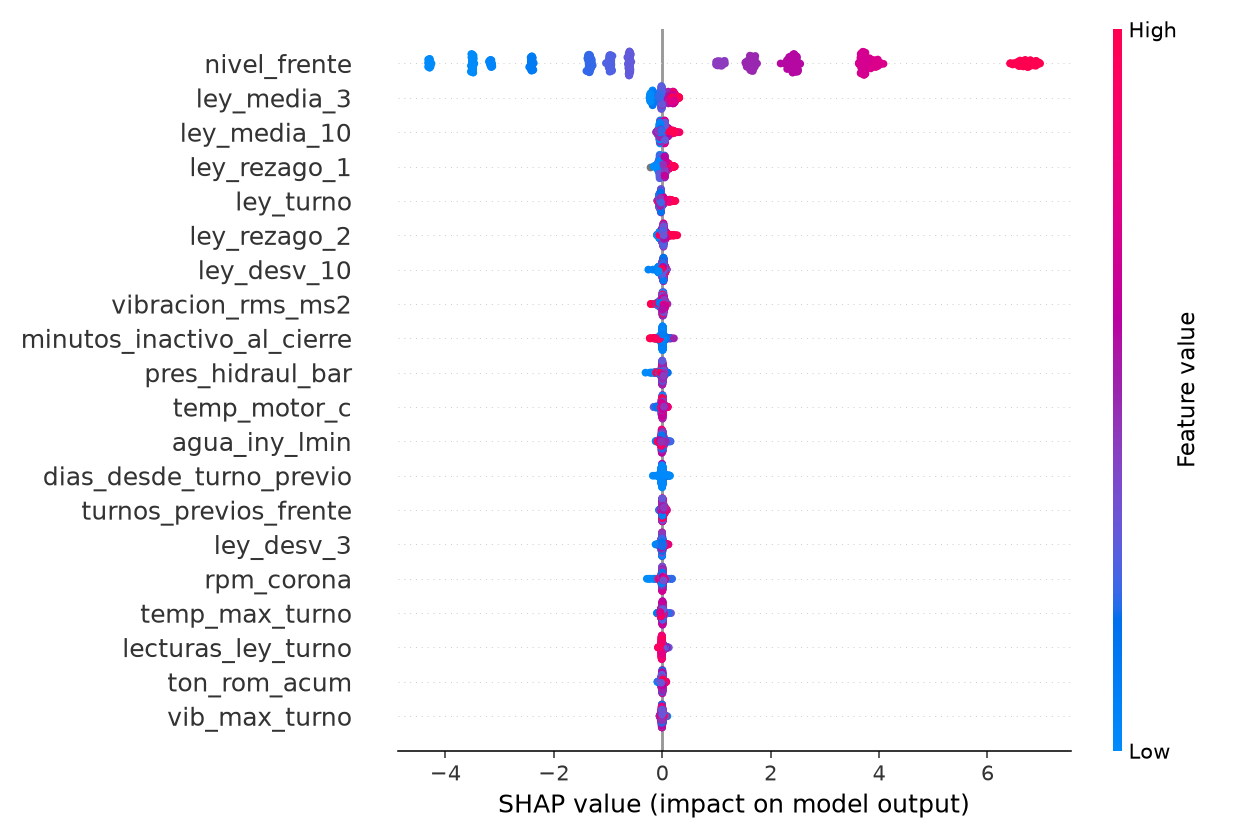

In [14]:
# La figura se guarda versionada y se muestra aquí, para que el notebook se pueda leer sin
# ejecutarlo y sin abrir el archivo por separado.
ruta_shap = explicador.figura_resumen(prueba, RAIZ / "figuras" / "shap_ley.png")
Image(str(ruta_shap))

**La respuesta a la pregunta del enunciado es que ningún sensor lo es.** El predictor
dominante es el nivel histórico del propio frente; los sensores de perforación reparten entre
sí una contribución que no se distingue del ruido.

Tiene sentido geológico y no es una limitación del modelo: la ley es una propiedad de la veta,
no de cómo se perfora. La presión hidráulica y las revoluciones de la corona describen el
esfuerzo sobre la roca, no su contenido de oro. La consecuencia operacional es concreta: para
mejorar esta predicción hace falta geología —ensayos, mapeo, sondajes de avanzada— y no más
telemetría.

<a id="falla"></a>
## 5. Clasificación de falla en las próximas 4 horas

Mismo recorrido y mismo código; lo único que cambia es el objetivo, los modelos, los baselines
y la métrica.

**Antes de modelar, qué contiene la etiqueta.** La etiqueta es cero por construcción cuando el
frente no registra eventos en la ventana. Si las fallas de cada evento fueran independientes con
la tasa de evento del extracto, la tasa de falla de una ventana con `n` eventos sería
`1 − (1 − p)^n`, y anticipar la falla sería anticipar cuántos eventos vendrán, es decir, si el
frente sigue operando. La celda siguiente compara la tasa observada contra esa hipótesis, sobre
el desarrollo, y construye además la variante por `equipo_id` que pide la letra del enunciado.

**Desbalance.** A nivel de evento la tasa de falla es 3.3%, pero la unidad de decisión es el
turno y ahí la tasa sube al 21.8%. Con ese balance no se remuestrea: SMOTE o el submuestreo del
negativo introducen más varianza de la que corrigen y distorsionan las probabilidades. El peso
de clase las distorsiona igual, así que no se supone: la fase A corre cada combinación con y sin
peso y se queda con la que valida mejor.

**Métrica principal: precisión media** (área bajo la curva de precisión-exhaustividad). El área
bajo la curva ROC se descarta porque con 78% de negativos se ve bien sin serlo. Y el costo de los
dos errores no es simétrico: un falso negativo es una perforadora detenida sin plan; un falso
positivo, una inspección de más. Eso empuja hacia la exhaustividad, pero no sin límite, porque una
alarma que se equivoca casi siempre deja de mirarse. Por eso se reporta además la exhaustividad
al 50% de precisión. Y se reporta la **precisión media con actividad**, calculada solo sobre las
ventanas en que el frente siguió registrando: es el detector de señal mecánica, porque un modelo
que solo anticipe la continuidad operativa se luce en la métrica global y vuelve a la tasa base
en esta.


In [15]:
from sklearn.metrics import average_precision_score

tasa_evento = float(eventos[domain.COLUMNA_FALLA].notna().mean())


def tabla_independencia(marco: pd.DataFrame) -> pd.DataFrame:
    """Tasa observada por número de eventos en la ventana, contra la independencia.

    La hipótesis es que las fallas de cada evento son independientes con la tasa de
    evento del extracto.
    """
    tramos = pd.cut(marco[COLUMNA_EVENTOS_VENTANA], [-1, 0, 3, 6, 9, 12, 60],
                    labels=["0", "1-3", "4-6", "7-9", "10-12", "13+"])
    tabla = (marco.groupby(tramos, observed=True)
             .agg(turnos=(COLUMNA_FALLA_HORIZONTE, "size"),
                  eventos_medios=(COLUMNA_EVENTOS_VENTANA, "mean"),
                  tasa_observada=(COLUMNA_FALLA_HORIZONTE, "mean")))
    tabla["si_fueran_independientes"] = 1 - (1 - tasa_evento) ** tabla["eventos_medios"]
    return tabla.round(4)


print(f"Tasa de falla por evento: {tasa_evento:.4f}\n")
print("Etiqueta por frente (la del modelo), sobre el desarrollo:")
print(tabla_independencia(desarrollo).to_string())
print(f"\nPrecisión media del oráculo que conoce el conteo de eventos de la ventana: "
      f"{average_precision_score(desarrollo[COLUMNA_FALLA_HORIZONTE], desarrollo[COLUMNA_EVENTOS_VENTANA]):.4f}"
      f" | tasa base: {desarrollo[COLUMNA_FALLA_HORIZONTE].mean():.4f}")

# La variante por equipo, que pide la letra del enunciado. Bajo el supuesto de extracto serial
# del EDA, equipo_id es una etiqueta repartida al azar sobre un flujo único: la ventana de un
# equipo contiene una fracción de los eventos y la etiqueta se vuelve más rara, no más predecible.
sin_etiqueta = desarrollo.drop(columns=[COLUMNA_FALLA_HORIZONTE, COLUMNA_EVENTOS_VENTANA,
                                        COLUMNA_VENTANA_OBSERVADA])
por_equipo = ConstructorEtiquetaFalla(columna_grupo=domain.COLUMNA_EQUIPO).agregar(
    sin_etiqueta, eventos_locales)
print(f"\nEtiqueta por equipo: tasa {por_equipo[COLUMNA_FALLA_HORIZONTE].mean():.4f}, "
      f"ventanas con registros del equipo {por_equipo[COLUMNA_VENTANA_OBSERVADA].mean():.1%}")
print(tabla_independencia(por_equipo).to_string())


Tasa de falla por evento: 0.0332

Etiqueta por frente (la del modelo), sobre el desarrollo:
                    turnos  eventos_medios  tasa_observada  si_fueran_independientes
eventos_en_ventana                                                                  
0                      536          0.0000          0.0000                    0.0000
1-3                    100          1.9600          0.0500                    0.0640
4-6                     82          4.7683          0.1220                    0.1486
7-9                    959          8.7842          0.2430                    0.2565
10-12                 1510         10.3397          0.2894                    0.2945
13+                      1         13.0000          0.0000                    0.3551

Precisión media del oráculo que conoce el conteo de eventos de la ventana: 0.2795 | tasa base: 0.2149

Etiqueta por equipo: tasa 0.0285, ventanas con registros del equipo 63.9%
                    turnos  eventos_medios  tasa_o

**Lectura.** La tasa observada reproduce la de eventos independientes en cada tramo: dada la
actividad, la falla es una moneda de 3.3% por evento, sin agrupamiento ni precedencia (el EDA
midió que P(falla | temperatura del evento anterior > 88 °C) es igual a la tasa base). El techo
del problema es el oráculo que conoce cuántos eventos tendrá la ventana, y ese es el número
contra el que hay que leer al modelo. La variante por equipo no cambia la conclusión: reparte
los mismos eventos independientes entre diez etiquetas y la falla se vuelve más rara, no más
anticipable.


In [16]:
experimento_falla = Experimento(
    desarrollo=desarrollo, prueba=prueba, registro=registro, problema=CLASIFICACION_FALLA)
tabla_variables_falla = experimento_falla.fase_variables()
tabla_variables_falla.round(4)

,modelo,conjunto_variables,estrategia_ventana,meses_ventana,peso_clase_positiva,precision_media,precision_media_entrenamiento,brecha_entrenamiento_validacion,desviacion_entre_pliegues,turnos_entrenamiento
0,lightgbm,ACTIVIDAD,expansiva,,1.000,0.2618,0.8256,0.5638,0.0247,1572.8
1,lightgbm,CONDICIONES,expansiva,,1.000,0.2607,1.0000,0.7393,0.0370,1572.8
2,lightgbm,ACTIVIDAD,expansiva,,3.654,0.2586,0.8073,0.5487,0.0262,1572.8
3,xgboost,ACTIVIDAD,expansiva,,3.654,0.2574,0.9346,0.6772,0.0231,1572.8
4,lightgbm,COMPLETO,expansiva,,1.000,0.2571,1.0000,0.7429,0.0294,1572.8
5,lightgbm,COMPLETO,expansiva,,3.654,0.2566,1.0000,0.7434,0.0210,1572.8
6,lightgbm,CONDICIONES,expansiva,,3.654,0.2564,1.0000,0.7436,0.0344,1572.8
7,xgboost,COMPLETO,expansiva,,3.654,0.2562,1.0000,0.7438,0.0276,1572.8
8,xgboost,CONDICIONES,expansiva,,1.000,0.2536,1.0000,0.7464,0.0304,1572.8
9,xgboost,ACTIVIDAD,expansiva,,1.000,0.2530,0.9141,0.6611,0.0199,1572.8


In [17]:
tabla_ventanas_falla = experimento_falla.fase_ventana()
print(f"Ventana elegida: {experimento_falla._ventana(experimento_falla.ventana_elegida_).nombre}"
      f" | la mejor deslizante supera a la expansiva por {experimento_falla.margen_ventana_:.4f}"
      f" contra una desviación entre pliegues de {experimento_falla.umbral_ventana_:.4f}")
tabla_ventanas_falla.round(4)


Ventana elegida: expansiva | la mejor deslizante supera a la expansiva por 0.0029 contra una desviación entre pliegues de 0.0219


,modelo,conjunto_variables,estrategia_ventana,meses_ventana,peso_clase_positiva,precision_media,precision_media_entrenamiento,brecha_entrenamiento_validacion,desviacion_entre_pliegues,turnos_entrenamiento
0,lightgbm,ACTIVIDAD,deslizante_18m,18,,0.2821,0.4795,0.1974,0.0302,1559.8
1,xgboost,ACTIVIDAD,deslizante_18m,18,,0.2797,0.3492,0.0695,0.0221,1559.8
2,xgboost,ACTIVIDAD,deslizante_6m,6,,0.2796,0.3648,0.0852,0.0262,781.0
3,xgboost,ACTIVIDAD,expansiva,,,0.2792,0.3487,0.0695,0.0219,1572.8
4,lightgbm,ACTIVIDAD,deslizante_6m,6,,0.2786,0.3806,0.1020,0.0218,781.0
5,xgboost,ACTIVIDAD,deslizante_12m,12,,0.2781,0.3525,0.0743,0.0236,1307.6
6,xgboost,ACTIVIDAD,deslizante_3m,3,,0.2768,0.4334,0.1566,0.0204,419.4
7,lightgbm,ACTIVIDAD,expansiva,,,0.2766,0.3882,0.1115,0.0176,1572.8
8,lightgbm,ACTIVIDAD,deslizante_12m,12,,0.2756,0.4769,0.2013,0.0238,1307.6
9,lightgbm,ACTIVIDAD,deslizante_3m,3,,0.2746,0.4209,0.1462,0.0225,419.4


In [18]:
final_falla = experimento_falla.fase_prueba()
print(f"Modelo ganador: {final_falla.modelo} | variables: {final_falla.conjunto} "
      f"| ventana: {final_falla.ventana} | peso de clase: {experimento_falla.peso_elegido_:.4f}"
      f" | turnos con que entrenó: {final_falla.turnos_entrenamiento}\n")
comparacion_falla = pd.DataFrame(
    [{"modelo": "ganador: " + final_falla.modelo, **final_falla.metricas.como_diccionario()}]
    + [{"modelo": nombre, **m.como_diccionario()}
       for nombre, m in final_falla.metricas_baselines.items()])
print(comparacion_falla.round(4).to_string(index=False))
print(f"\n¿Le gana al baseline de actividad? {final_falla.le_gana_al_baseline_fuerte}")

# El techo del problema, sobre la misma prueba: un oráculo que conociera cuántos eventos va a
# registrar el frente en la ventana. Ningún modelo puede saberlo al cierre del turno.
etiqueta_prueba = prueba[COLUMNA_FALLA_HORIZONTE]
print(f"\nTecho del problema (oráculo del conteo de eventos en la ventana): "
      f"precisión media {average_precision_score(etiqueta_prueba, prueba[COLUMNA_EVENTOS_VENTANA]):.4f}")
print(f"Oráculo binario (hubo registros o no): "
      f"precisión media {average_precision_score(etiqueta_prueba, prueba[COLUMNA_VENTANA_OBSERVADA]):.4f}")


2026/08/30 14:07:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/30 14:07:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/30 14:07:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/30 14:07:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


/Users/amadorcallelo/projects/personal/pruebas_tecnicas/mineros/data_scientist_senior/repositorio-ds-mine/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Modelo ganador: xgboost | variables: ACTIVIDAD | ventana: expansiva | peso de clase: 1.0000 | turnos con que entrenó: 3188

              modelo  precision_media  exhaustividad_al_50_pct_precision  area_bajo_roc  error_brier  tasa_base_falla  levante_sobre_azar  precision_media_con_actividad  tasa_base_con_actividad  turnos
    ganador: xgboost           0.2817                              0.011         0.5955       0.1689           0.2271              1.2404                         0.2879                   0.2678   797.0
baseline_prevalencia           0.2271                              0.000         0.5000       0.1757           0.2271              1.0000                         0.2678                   0.2678   797.0
baseline_tasa_frente           0.2245                              0.000         0.4931       0.1763           0.2271              0.9885                         0.2632                   0.2678   797.0
  baseline_actividad           0.2642                              0

Successfully registered model 'aurum_falla_4h'.
Created version '1' of model 'aurum_falla_4h'.


In [19]:
final_falla.detalle_por_frente.round(4)

,frente_id,probabilidad_media,tasa_real,turnos
0,FR-N2-01,0.2374,0.2667,45
1,FR-S1-06,0.2010,0.2667,75
2,FR-N1-03,0.1954,0.2609,23
3,FR-S2-03,0.1843,0.2394,71
4,FR-C1-05,0.2208,0.2336,107
5,FR-S2-08,0.2336,0.2321,56
6,FR-C2-02,0.2620,0.2237,76
7,FR-N1-07,0.2252,0.2203,59
8,FR-C1-01,0.2702,0.2174,46
9,FR-C2-07,0.2182,0.2105,95


**La probabilidad se puede leer como lo que dice ser.** La fase A eligió el modelo sin peso de
clase, y las dos columnas van juntas frente a frente: la media predicha va de 0.16 a 0.27 con la
tasa real entre 0.17 y 0.27, y el error de Brier del modelo (0.1689) queda por debajo del de una
constante (0.1757). En la versión anterior de este notebook, con peso de clase, la probabilidad
media por frente iba de 0.34 a 0.50 contra la misma tasa real: reequilibrar la pérdida desplaza
las probabilidades hacia arriba y solo conserva el ordenamiento. Se descartó por medición, no
por preferencia, y el mecanismo sigue disponible como parámetro para un desbalance severo.


### SHAP del clasificador: el mismo sensor a tres horizontes

Si la temperatura anticipara la falla, tendría que verse en la atribución del clasificador. El
clasificador registrado no lleva sensores, así que explicarlo no puede mostrarla por
construcción; por eso se explican tres cosas: el registrado, un clasificador con todas las
variables y los hiperparámetros del ganador —para que los sensores compitan de verdad—, y una
sonda a nivel de evento que mide el mismo sensor contra la falla del mismo evento (detección,
no pronóstico) y contra la del evento siguiente, unos 25 minutos después. La precisión media del
clasificador con todas las variables es una mirada diagnóstica a la prueba, no una selección.


In [20]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline

from aurum_pipeline.modeling.explain import ExplicadorFalla, SondaContemporanea
from aurum_pipeline.modeling.features import COMPLETO, CodificadorNivelFrente, SelectorVariables

print(f"1. Clasificador registrado ({final_falla.conjunto}, {final_falla.modelo}):")
print(ExplicadorFalla(final_falla.pipeline).importancia(prueba).round(2).to_string(index=False))

# 2. Todas las variables con los mismos hiperparámetros del ganador: los sensores compiten.
con_todo = Pipeline([
    ("nivel", CodificadorNivelFrente()),
    ("variables", SelectorVariables(conjunto=COMPLETO)),
    ("modelo", clone(final_falla.pipeline.named_steps["modelo"])),
]).fit(desarrollo, desarrollo[COLUMNA_FALLA_HORIZONTE])
p_todo = con_todo.predict_proba(prueba)[:, 1]
print(f"\n2. Clasificador con las {len(COMPLETO.columnas)} variables: precisión media sobre la prueba "
      f"{average_precision_score(prueba[COLUMNA_FALLA_HORIZONTE], p_todo):.4f} "
      f"(registrado: {final_falla.metricas.valor_principal:.4f}; diagnóstico, no selección)")
print(ExplicadorFalla(con_todo).importancia(prueba).head(12).round(2).to_string(index=False))

# 3. El mismo sensor a horizonte cero y a un evento, a nivel de evento.
sonda = SondaContemporanea().ajustar(eventos_locales, corte=prueba[domain.COLUMNA_INICIO_TURNO].min())
print("\n3. Sonda a nivel de evento, evaluada sobre los eventos del periodo de prueba:")
print(sonda.resultados_.round(4).to_string(index=False))
print("   Atribución del modelo contemporáneo:")
print(sonda.importancia_.round(2).to_string(index=False))


1. Clasificador registrado (ACTIVIDAD, xgboost):
                  variable  contribucion_media_log_odds  contribucion_pct
minutos_inactivo_al_cierre                         0.50             71.50
              nivel_frente                         0.10             14.39
             eventos_turno                         0.08             11.83
                 turno_num                         0.02              2.28



2. Clasificador con las 28 variables: precisión media sobre la prueba 0.2971 (registrado: 0.2817; diagnóstico, no selección)
                  variable  contribucion_media_log_odds  contribucion_pct
minutos_inactivo_al_cierre                         0.48             40.82
     turnos_previos_frente                         0.08              6.39
              ley_rezago_2                         0.05              4.57
               avance_mmin                         0.05              4.39
            temp_max_turno                         0.05              3.94
        lecturas_ley_turno                         0.05              3.87
                rpm_corona                         0.04              3.50
              ton_rom_acum                         0.04              3.45
              nivel_frente                         0.04              3.10
   dias_desde_turno_previo                         0.04              3.07
                ley_desv_3                         0.03     


3. Sonda a nivel de evento, evaluada sobre los eventos del periodo de prueba:
       horizonte  eventos  precision_media  tasa_base_falla  levante_sobre_azar  area_bajo_roc
    mismo evento    10225           0.1364           0.0348              3.9191         0.7068
evento siguiente    10212           0.0359           0.0349              1.0300         0.4971
   Atribución del modelo contemporáneo:
         variable  contribucion_media_log_odds  contribucion_pct
     temp_motor_c                         0.74             62.84
    agua_iny_lmin                         0.09              7.25
 pres_hidraul_bar                         0.08              6.79
vibracion_rms_ms2                         0.08              6.55
     ton_rom_acum                         0.07              5.68
      avance_mmin                         0.06              5.50
       rpm_corona                         0.06              5.40


**Lectura.** La señal del sensor muere dentro de un evento. A horizonte cero la temperatura
domina la atribución con el 62.8% y el modelo levanta 3.9× la tasa base: eso es detección, y
es lo que sostiene la alarma de 88 °C. Veinticinco minutos después la precisión media vuelve a
la base (1.03×) y el ROC a 0.50: la temperatura de un evento no dice nada sobre el siguiente. A
cuatro horas pesa lo mismo que el avance o las rpm —la firma del ruido— y lo que manda son los
minutos de inactividad al cierre, en el registrado (71.5%) y en el de 28 variables (40.8%). El
rango útil del sensor es contemporáneo. Y una debilidad del protocolo que hay que declarar: el
clasificador con las 28 variables da 0.2971 contra 0.2817 del registrado, porque la fase A
elige el conjunto con hiperparámetros por defecto y esos memorizan los conjuntos anchos; es una
mirada diagnóstica a la prueba, no una selección, y la comparación legítima —fase B con todos
los conjuntos— queda como límite declarado.


<a id="conclusiones"></a>
## 6. Conclusiones

Las cifras de esta sección salen del registro de experimentos, no de un archivo aparte.

In [21]:
for nombre_experimento in (domain.EXPERIMENTO_LEY, domain.EXPERIMENTO_FALLA):
    registro.usar_experimento(nombre_experimento)
    corridas = registro.tabla_de_corridas()
    print(f"{nombre_experimento}: {len(corridas)} corridas padre")
    if len(corridas):
        print("  fases:", corridas["tags.fase"].value_counts().to_dict())

registro.usar_experimento(domain.EXPERIMENTO_LEY)
resumen = registro.tabla_de_corridas(fase="fase_b__ventana__ley")
columnas = [c for c in ("tags.mlflow.runName", "params.estrategia_ventana",
                        "metrics.error_medio_g_por_tonelada",
                        "metrics.desviacion_entre_pliegues") if c in resumen.columns]
resumen[columnas].sort_values("metrics.error_medio_g_por_tonelada").head(12)

ley_oro_turno_siguiente: 31 corridas padre
  fases: {'fase_b__ventana__ley': 20, 'fase_a__variables__ley': 8, 'fase_c__prueba__ley': 3}


falla_mecanica_4h: 55 corridas padre
  fases: {'fase_b__ventana__falla_4h': 35, 'fase_a__variables__falla_4h': 16, 'fase_c__prueba__falla_4h': 4}


,tags.mlflow.runName,params.estrategia_ventana,metrics.error_medio_g_por_tonelada,metrics.desviacion_entre_pliegues
8,xgboost__deslizante_12m__MINIMO,deslizante_12m,0.380284,0.015972
9,lightgbm__deslizante_12m__MINIMO,deslizante_12m,0.380389,0.016877
13,lightgbm__deslizante_18m__MINIMO,deslizante_18m,0.380498,0.016910
10,baseline_nivel_frente__deslizante_12m,deslizante_12m,0.380515,0.016073
17,lightgbm__expansiva__MINIMO,expansiva,0.380597,0.017078
16,xgboost__expansiva__MINIMO,expansiva,0.380718,0.016546
12,xgboost__deslizante_18m__MINIMO,deslizante_18m,0.380762,0.016616
18,baseline_nivel_frente__expansiva,expansiva,0.380892,0.016496
14,baseline_nivel_frente__deslizante_18m,deslizante_18m,0.380897,0.016504
5,lightgbm__deslizante_6m__MINIMO,deslizante_6m,0.381495,0.016951


In [22]:
print(f"""
REGRESIÓN DE LEY
  Modelo ganador ...... {final_ley.modelo} sobre {final_ley.conjunto}, ventana {final_ley.ventana}
  Error sobre prueba .. {final_ley.metricas.error_medio_g_por_tonelada:.4f} g/t
  Baseline del frente . {final_ley.metricas_baselines['baseline_nivel_frente'].valor_principal:.4f} g/t
  Baseline naive ...... {final_ley.metricas_baselines['baseline_persistencia'].valor_principal:.4f} g/t
  ¿El modelo gana? .... {final_ley.le_gana_al_baseline_fuerte}

CLASIFICACIÓN DE FALLA A 4 HORAS
  Modelo ganador ...... {final_falla.modelo} sobre {final_falla.conjunto}, ventana {final_falla.ventana}, peso {experimento_falla.peso_elegido_:.2f}
  Precisión media ..... {final_falla.metricas.valor_principal:.4f}
  Tasa base ........... {prueba[COLUMNA_FALLA_HORIZONTE].mean():.4f}
  Con actividad ....... {final_falla.metricas.como_diccionario()['precision_media_con_actividad']:.4f} (tasa base {final_falla.metricas.como_diccionario()['tasa_base_con_actividad']:.4f})
  Baseline del frente . {final_falla.metricas_baselines['baseline_tasa_frente'].valor_principal:.4f}
  Baseline actividad .. {final_falla.metricas_baselines['baseline_actividad'].valor_principal:.4f}
  Techo (oráculo) ..... {average_precision_score(prueba[COLUMNA_FALLA_HORIZONTE], prueba[COLUMNA_EVENTOS_VENTANA]):.4f}
  ¿El modelo gana? .... {final_falla.le_gana_al_baseline_fuerte}
""")



REGRESIÓN DE LEY
  Modelo ganador ...... lightgbm sobre MINIMO, ventana expansiva
  Error sobre prueba .. 0.3979 g/t
  Baseline del frente . 0.3975 g/t
  Baseline naive ...... 0.5491 g/t
  ¿El modelo gana? .... False

CLASIFICACIÓN DE FALLA A 4 HORAS
  Modelo ganador ...... xgboost sobre ACTIVIDAD, ventana expansiva, peso 1.00
  Precisión media ..... 0.2817
  Tasa base ........... 0.2271
  Con actividad ....... 0.2879 (tasa base 0.2678)
  Baseline del frente . 0.2245
  Baseline actividad .. 0.2642
  Techo (oráculo) ..... 0.2984
  ¿El modelo gana? .... True



### Lectura

**El modelo empata con el baseline; no le gana.** La fase C da 0.3979 g/t contra 0.3975 del
nivel del frente: 0.0004 g/t a favor del baseline, más de cuarenta veces menos que la dispersión
del propio error entre pliegues. Leerlo como derrota sería tan equivocado como leer la versión
anterior —0.0001 a favor del modelo— como victoria: ambos están sobre el mismo techo.

**La ley no es predecible más allá del nivel del frente.** El techo del problema —la media del
frente calculada con todo el histórico, que ningún modelo puede usar— explica el 97.57% de la
varianza, y el baseline causal llega al 97.53%. Entre esas dos cifras está todo el espacio
disponible, y LightGBM y XGBoost no lo ocupan: con el conjunto `MINIMO` reproducen exactamente
el baseline, y al agregarles variables empeoran. La brecha dice por qué: con hiperparámetros
por defecto, XGBoost sobre `COMPLETO` baja el error de entrenamiento a 0.02 g/t y sube el de
validación a 0.48. Memoriza. El entregable no es un modelo mejor: es la medición de dónde está
el límite y de qué pasa cuando se intenta cruzarlo.

**La ventana expansiva es la hipótesis por defecto, y el experimento la conserva.** La mejor
deslizante la supera por 0.0003 g/t con 0.017 de desviación entre pliegues en la regresión, y
por 0.0029 con 0.022 en la clasificación: empates en los dos casos. El nivel de un frente no
deriva —su desviación entre trimestres es 0.14 g/t contra 3.69 g/t entre frentes—, así que no
hay régimen viejo que descartar. Recortar la ventana no hace al modelo más adaptativo, lo hace
más inestable: a tres meses la desviación entre pliegues se multiplica por cinco y la brecha
casi se triplica. El modelo final entrenó con los 3188 turnos del desarrollo, y así quedó
registrado.

**La falla a cuatro horas tiene señal, y la señal es de actividad.** La etiqueta reproduce la de
eventos independientes al 3.3% cada uno en todos los tramos: dada la actividad, la falla es una
moneda, y anticiparla es anticipar si el frente sigue perforando. `ACTIVIDAD` —cuatro
variables— gana a `COMPLETO` con 27; el modelo da 0.2817 de precisión media contra 0.2271 de
base, a 0.0167 del oráculo que conoce cuántos eventos tendrá la ventana (0.2984) y 0.0175 por
encima de una tabla de cinco tasas por tramo de minutos de inactividad (0.2642). Condicionado
a las ventanas con registros, el residuo (0.2879 contra 0.2678) es actividad dentro de la
actividad. La exhaustividad al 50% de precisión es del 1.1%. Un modelo así sirve para programar,
no para mantener; lo que sí sostiene el extracto sobre la máquina es la **detección
contemporánea**, donde la tasa de falla pasa de 3.3% por debajo de 88 °C a 22.7% por encima.
Eso es un umbral operacional, no un modelo, y está documentado en el EDA.

**El sobreajuste quedó medido.** Con hiperparámetros por defecto, todo clasificador con más de
cuatro variables da precisión media 1.0000 sobre el entrenamiento y 0.25 sobre la validación; la
búsqueda de hiperparámetros baja la brecha a 0.07–0.20 y el baseline de actividad no memoriza
(−0.004). La brecha residual no se corrige con más regularización, porque el techo es 0.30 y
no 1.0. Y el peso de clase se comparó con y sin: sin peso gana en validación y deja la
probabilidad calibrada.

**Lo que haría falta para que esto mejore.** Para la ley, datos de geología; y sobre la
medición, el residuo del oráculo va de 1.03 g/t con tres lecturas a 0.31 con trece, así que el
piso lo pone la sonda. Para la falla, telemetría con persistencia real: en este extracto la
correlación de la temperatura con su propio valor anterior en el mismo equipo es 0.004, y las
fallas de eventos consecutivos son independientes. Sin memoria en la señal no hay degradación
que anticipar, y la precisión media con actividad sería la primera métrica en moverse cuando
la haya.
